In [331]:
import sys  # noqa: I001

sys.path.append("..")


import typing

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score
from src.eval_utils.mmlu_utils import category_from_subject, subcategory_from_subject


pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)


matplotlib.rcParams["text.usetex"] = True
matplotlib.rcParams["text.latex.preamble"] = "\\usepackage{libertinus}"

sns.set_style("white")
sns.set_context("paper", font_scale=1.2)

In [332]:
dataset = load_dataset("../data/mmlu_predictions", data_files="test.parquet", split="train")
df = dataset.to_pandas()
df = typing.cast(pd.DataFrame, df)

EXCLUDE_MIIA_14B = True

MODELS_RENAME = {
    "../MIIA-14B": "MIIA-14B",
    "Fastweb/FastwebMIIA-7B": "MIIA-7B",
    "Qwen/Qwen3.5-9B": "Qwen3.5-9B",
    "Qwen/Qwen3.5-27B": "Qwen3.5-27B",
    "sapienzanlp/Minerva-7B-instruct-v1.0": "Minerva",
    "swap-uniba/LLaMAntino-3-ANITA-8B-Inst-DPO-ITA": "LLaMAntino-3",
    "utter-project/EuroLLM-9B-Instruct-2512": "EuroLLM-9B",
    "utter-project/EuroLLM-22B-Instruct-2512": "EuroLLM-22B",
    "swiss-ai/Apertus-8B-Instruct-2509": "Apertus-8B",
    "swiss-ai/Apertus-70B-Instruct-2509": "Apertus-70B",
    "Almawave/Velvet-14B": "Velvet-14B",
}

LANGS_ORDER = ["English", "Italian", "Venetian", "Lombard", "Sicilian", "Friulian", "Ligurian"]
MODELS_ORDER = [
    "Minerva",
    "MIIA-7B",
    "MIIA-14B",
    "Velvet-14B",
    "LLaMAntino-3",
    "EuroLLM-9B",
    "EuroLLM-22B",
    "Apertus-8B",
    "Apertus-70B",
    "Qwen3.5-9B",
    "Qwen3.5-27B",
]

if EXCLUDE_MIIA_14B:
    MODELS_ORDER = [model for model in MODELS_ORDER if model != "MIIA-14B"]

MODELS_COLORS = {
    "Minerva": "#d62728",
    "MIIA-7B": "#F5E37A",
    "MIIA-14B": "#D4B200",
    "Velvet-14B": "#17becf",
    "LLaMAntino-3": "#2ca02c",
    "EuroLLM-9B": "#aec7e8",
    "EuroLLM-22B": "#1f77b4",
    "Apertus-8B": "#ffbb78",
    "Apertus-70B": "#ff7f0e",
    "Qwen3.5-9B": "#c5b0d5",
    "Qwen3.5-27B": "#9467bd",
}

df["model"] = df["model"].map(MODELS_RENAME)

if EXCLUDE_MIIA_14B:
    df = df[df["model"] != "MIIA-14B"].copy()

df["model"] = df["model"].astype(pd.CategoricalDtype(MODELS_ORDER, ordered=True))
df["lang"] = df["lang"].astype(pd.CategoricalDtype(LANGS_ORDER, ordered=True))

df["category"] = df["subset"].map(category_from_subject)
df["subcategory"] = df["subset"].map(subcategory_from_subject)

In [333]:
df = typing.cast(pd.DataFrame, df)
models = df["model"].unique()

for _, model in enumerate(models):
    model_df = df[df["model"] == model]
    pred = model_df["prediction"].astype(str)
    print(f"Model: {model}")
    counts = pred.value_counts()[:20]  # Show top 20 predictions
    print(", ".join(f"{label} ({count})" for label, count in counts.items()))
    print()

Model: Velvet-14B
A (13818), C (10643), B (9967), D (2834), I (28), 1 (6), III (2), 2 (2), a (1), Che (1), Univers (1), S (1), 8 (1), Canada (1), UN (1), X (1), Y (1), Sag (1)

Model: MIIA-7B
A (11325), C (11050), B (8436), D (6309), S (93), Ve (5), I (4), T (4), 300 (4), i (4), II (3), 5 (3), pen (3), W (3), H (2), Respons (2), 95 (2), 0 (2), 8 (2), Gi (2)

Model: nan


Model: Qwen3.5-27B
C (10016), D (9702), B (9106), A (8486)

Model: Qwen3.5-9B
C (10630), B (9509), D (8794), A (8377)

Model: Minerva
A (27175), C (6489), D (1577), B (1462), II (140), I (103), III (90), ii (61), X (20), 1 (16), 2 (14), i (9), 7 (7), E (7), iii (7), 3 (6), M (5), Artic (5), x (5), V (4)

Model: LLaMAntino-3
D (11817), B (9696), C (8304), A (5956), 3 (142), 1 (117), 2 (111), 4 (71), 0 (68), 8 (65), 5 (62), 7 (48), 6 (47), 9 (44), 12 (30), 20 (26), 10 (21), 25 (20), 100 (16), 15 (15)

Model: Apertus-70B
C (10191), B (10047), A (9707), D (7361), 2 (2), 7 (1), II (1)

Model: Apertus-8B
C (10709), B (10546)

In [334]:
# row = df[df["prediction"].str.contains("III")].iloc[1]
# print(row["question"])
# print(row["choices"])
# print(row["answer"])

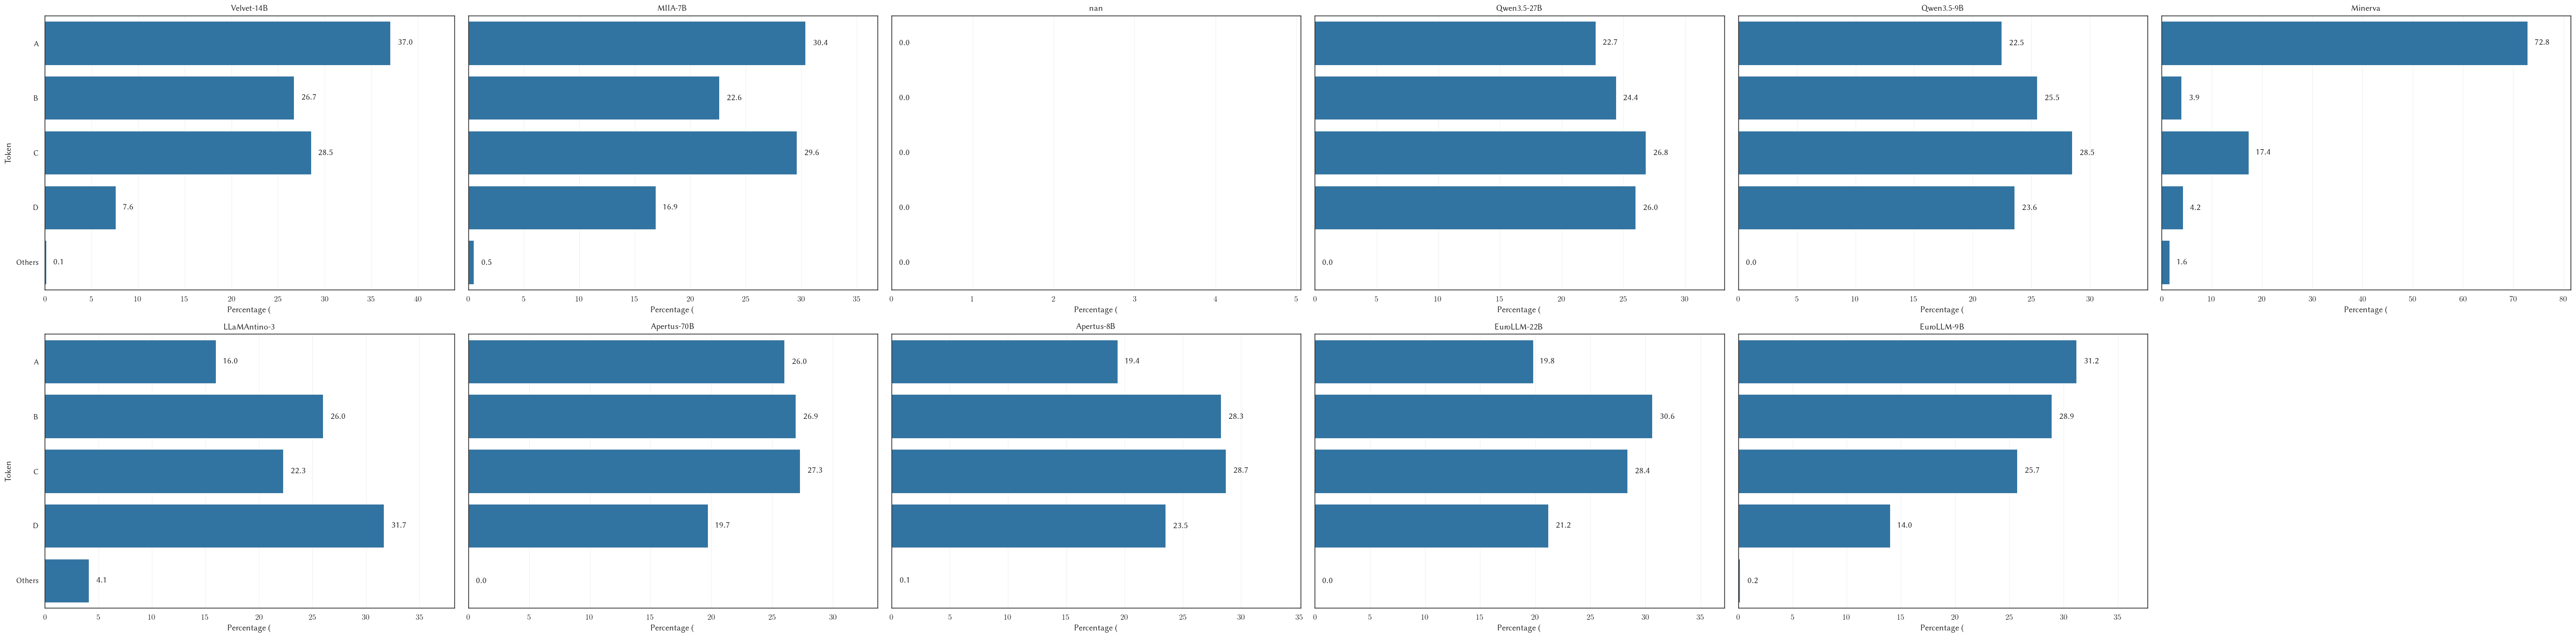

In [335]:
# token percentage per model with non A/B/C/D aggregated as Others
ncols = len(models) // 2 + len(models) % 2
fig, axes = plt.subplots(nrows=2, ncols=ncols, figsize=(8 * ncols, 12), sharey=True)
axes = np.atleast_1d(axes).flatten()

valid_tokens = {"A", "B", "C", "D"}
token_order = ["A", "B", "C", "D", "Others"]

for i, model in enumerate(models):
    model_df = df[df["model"] == model]
    pred = model_df["prediction"].astype(str).str.strip().str.upper()

    grouped = pred.where(pred.isin(valid_tokens), "Others")
    token_pct = grouped.value_counts(normalize=True).reindex(token_order, fill_value=0).mul(100)

    sns.barplot(x=token_pct.values, y=token_pct.index, ax=axes[i])
    axes[i].set_title(f"{model}")
    axes[i].set_xlabel("Percentage (%)")
    axes[i].set_ylabel("Token")
    axes[i].set_xlim(0, axes[i].get_xlim()[1] + 5)  # Ensure x-axis starts at 0
    axes[i].grid(axis="x", alpha=0.25)

    for container in axes[i].containers:
        axes[i].bar_label(container, fmt="%.1f%%", padding=10, fontsize=12)

# hide any unused subplots
for j in range(len(models), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [336]:
# print percentage of others tokens per model and language
others_count = df[~df["prediction"].isin(valid_tokens)].groupby(["model", "lang"], observed=False).size()
total_count = df.groupby(["model", "lang"], observed=False).size()
df_total = total_count.unstack(level=0).T.fillna(0).astype(int)

df_percentage = others_count.unstack(level=0).T.fillna(0).astype(int)
df_percentage["Total"] = df_percentage.sum(axis=1)
df_percentage = df_percentage.sort_values("Total", ascending=False)
df_percentage["Percentage"] = df_percentage["Total"] / df_total.sum(axis=1) * 100
df_percentage["Percentage"] = df_percentage["Percentage"].round(2).astype(str) + "%"
df_percentage

lang,English,Italian,Venetian,Lombard,Sicilian,Friulian,Ligurian,Total,Percentage
model,,,,,,,,,
LLaMAntino-3,491,364,179,59,250,89,105,1537,4.12%
Minerva,37,76,85,195,40,74,100,607,1.63%
MIIA-7B,11,6,34,5,3,75,56,190,0.51%
EuroLLM-9B,3,2,1,4,0,6,42,58,0.16%
Velvet-14B,10,11,15,5,3,2,2,48,0.13%
Apertus-8B,1,1,6,3,3,3,9,26,0.07%
Apertus-70B,1,0,0,0,2,0,1,4,0.01%
EuroLLM-22B,0,0,0,0,1,0,0,1,0.0%
Qwen3.5-9B,0,0,0,0,0,0,0,0,0.0%


In [337]:
USE_LOGPROBS = True


def map_prediction(label: str) -> int:
    label_to_id = {"A": 0, "B": 1, "C": 2, "D": 3}
    return label_to_id.get(label, -1)


if USE_LOGPROBS:
    # using logprobs
    df["prediction"] = df["probs"].map(lambda x: np.argmax(x))
else:
    # using predicted token (exact match)
    df["prediction"] = df["prediction"].map(lambda x: map_prediction(x.strip()))

df["confidence"] = df["probs"].map(np.max)
df["correct"] = (df["prediction"] == df["answer"]).astype(int)

In [338]:
# compute F1 metrics per language and model
df = typing.cast(pd.DataFrame, df)


def compute_metrics(group: pd.DataFrame) -> pd.Series:
    return pd.Series(
        {
            "f1_macro": f1_score(group["answer"], group["prediction"], average="macro", zero_division=0),
            "f1_weighted": f1_score(group["answer"], group["prediction"], average="weighted", zero_division=0),
            "accuracy": accuracy_score(group["answer"], group["prediction"]),
            "avg_confidence": group["confidence"].mean(),
        }
    )


metrics_df = df.groupby(["lang", "model"], as_index=False, observed=True).apply(compute_metrics, include_groups=False)  # pyright: ignore[reportCallIssue]

In [352]:
(df["answer"] == df["prediction"]).mean()

np.float64(0.530637655027899)

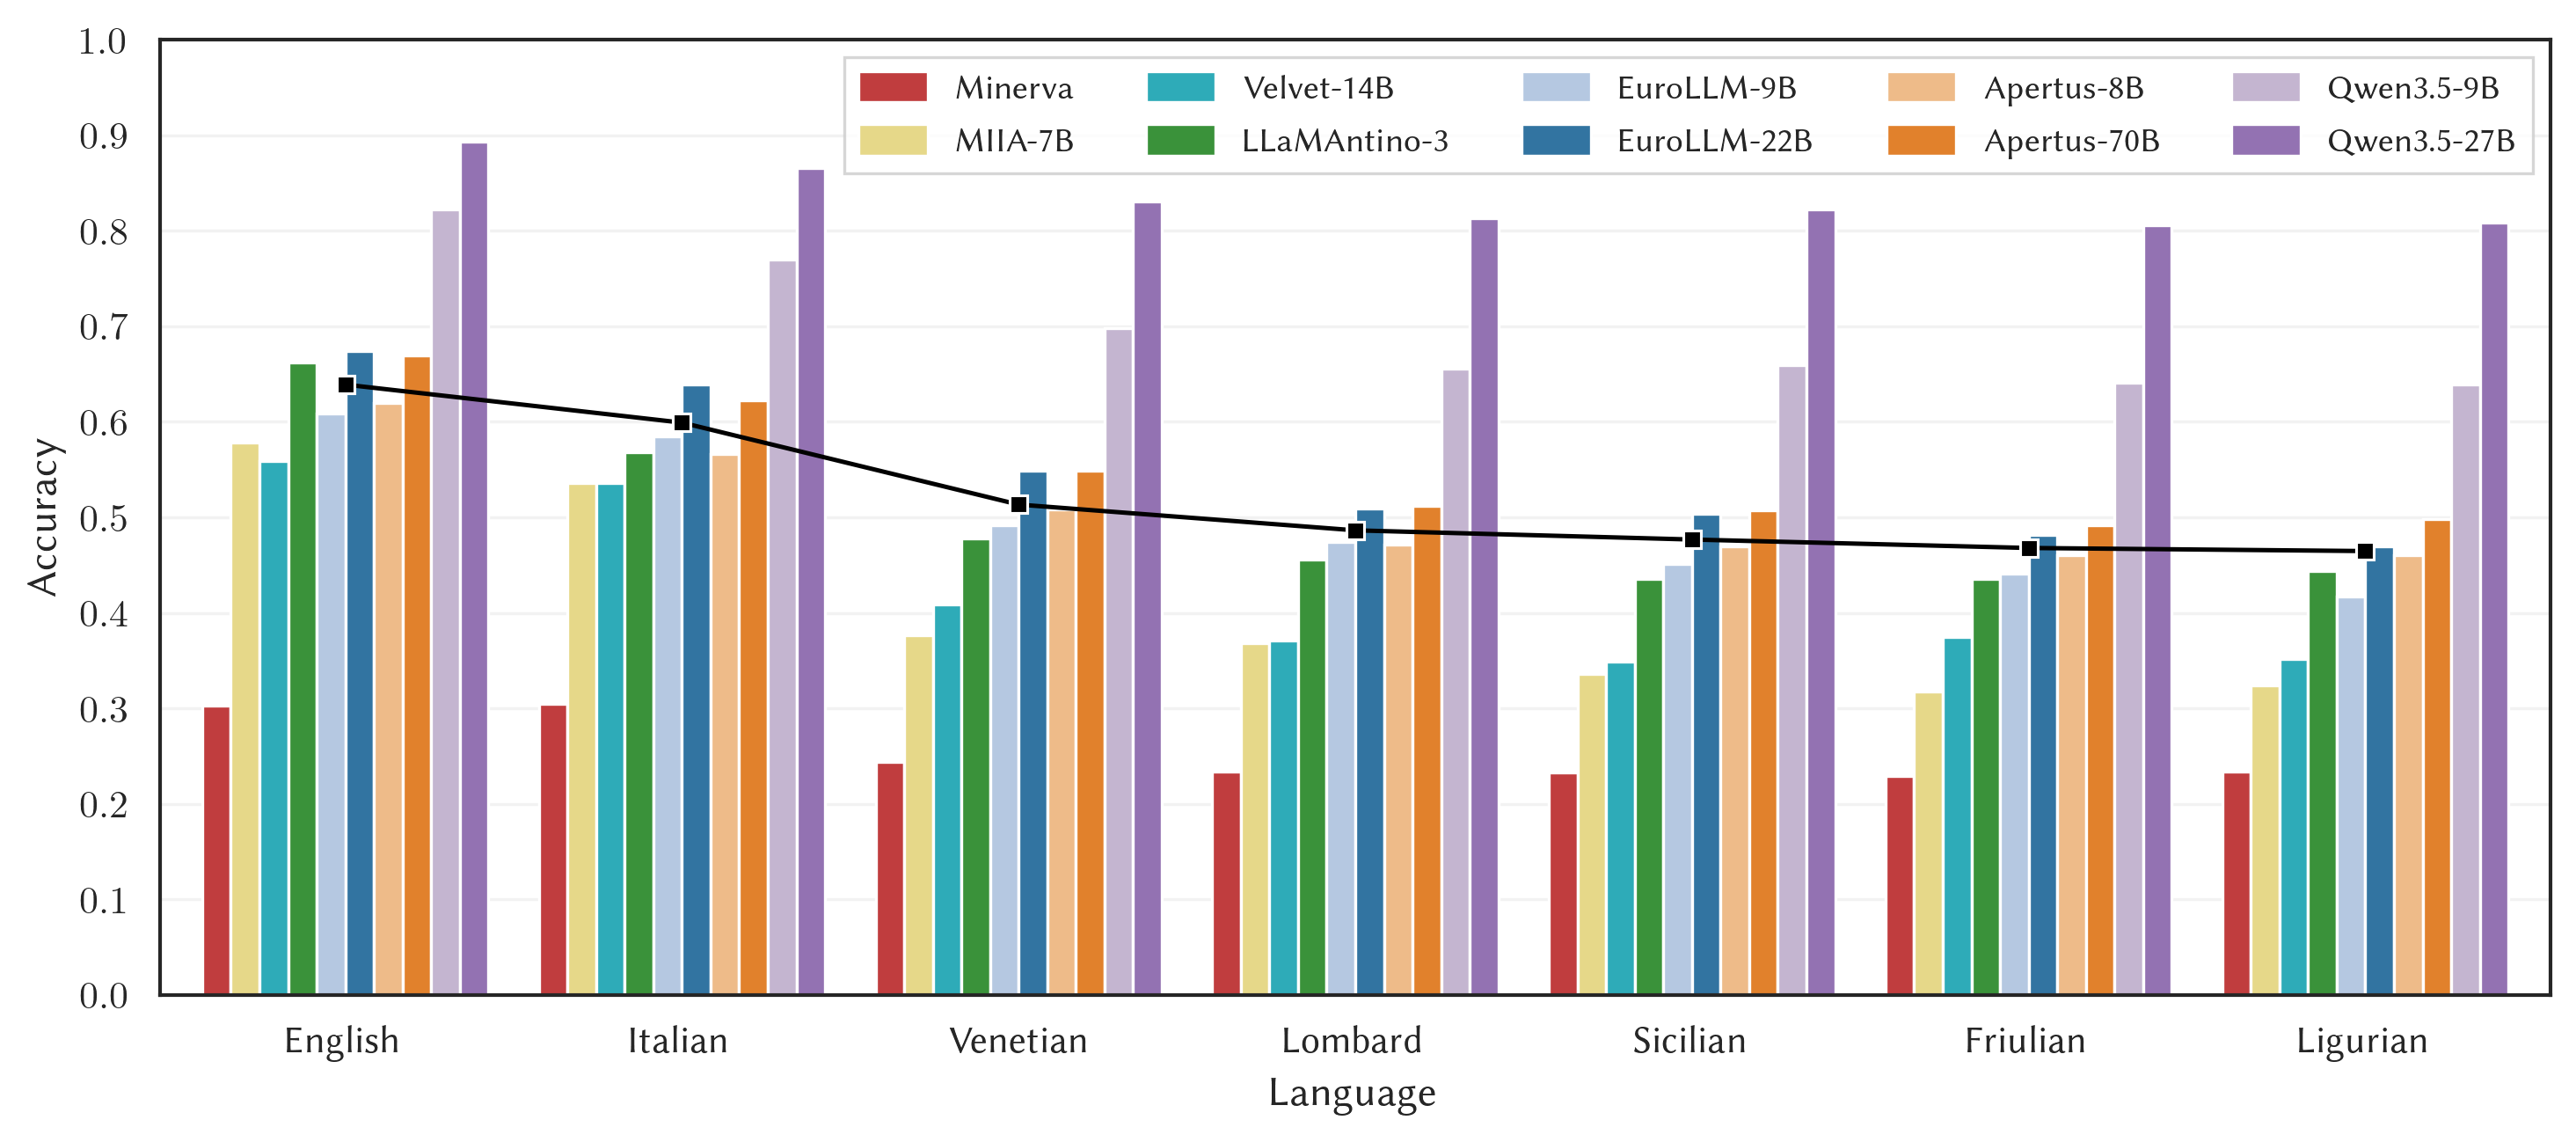

In [360]:
metrics_df = metrics_df.sort_values(["model"])

sns.set_style("white")

fig = plt.figure(figsize=(11.69, 4.7), dpi=300, constrained_layout=False)
ax = sns.barplot(data=metrics_df, x="lang", y="accuracy", hue="model", palette=MODELS_COLORS, width=0.85)
sns.lineplot(
    data=metrics_df,
    x="lang",
    y="accuracy",
    legend=False,
    color="black",
    markers="s",
    style=True,
    errorbar=None,
)
# ax.set_title("Accuracy by Language and Model")
ax.set_xlabel("Language")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0.0, 1.01, 0.1))
ax.set_xlim(-0.55, len(LANGS_ORDER) - 0.45)
ax.grid(axis="y", alpha=0.25)

# legend inside the plot top center with one row and no frame
ax.legend(
    ncols=len(models) // 2,
    loc="best",
    frameon=True,
    shadow=False,
    fancybox=False,
    bbox_to_anchor=(1.0, 1),
    handleheight=1.0,
    fontsize=9.5,
)
plt.savefig("../outputs/plots/mmlu_accuracy.png", bbox_inches="tight", dpi=300)
plt.savefig("../outputs/plots/mmlu_accuracy.pdf", bbox_inches="tight", dpi=300)

<Axes: xlabel='lang', ylabel='f1_macro'>

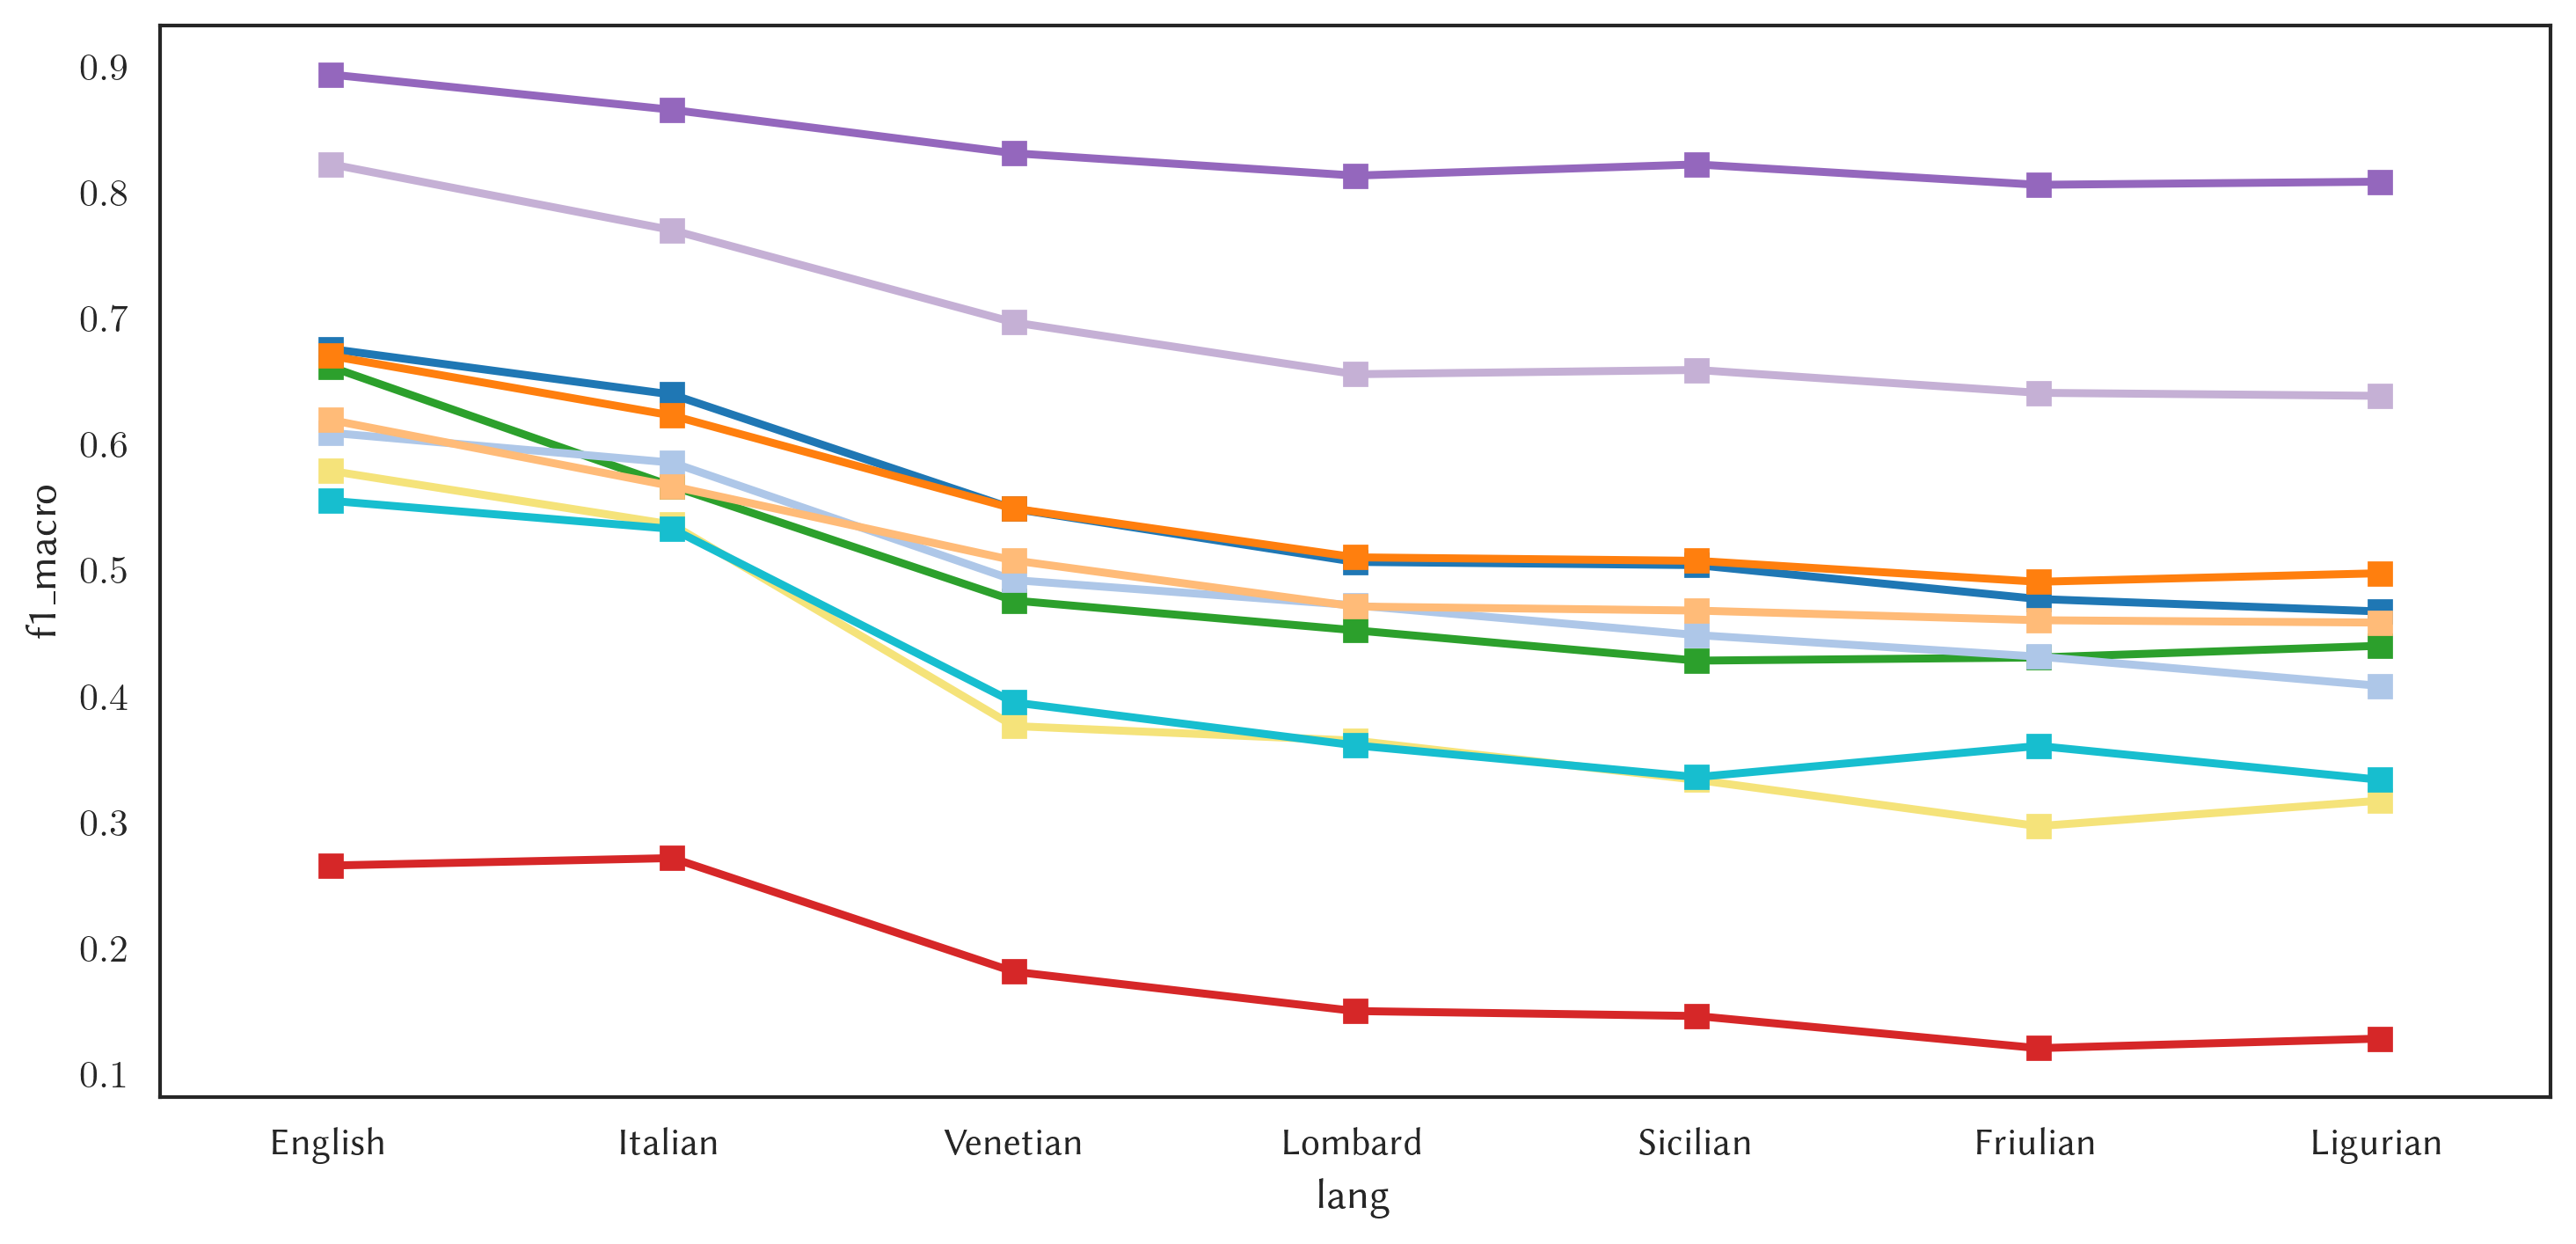

In [357]:
plt.figure(figsize=(11.69, 5.27), dpi=300)
sns.pointplot(data=metrics_df, x="lang", y="f1_macro", hue="model", palette=MODELS_COLORS, legend=False, markers="s")

In [342]:
avg_metrics = metrics_df.pivot(index="model", columns="lang", values="accuracy")
avg_metrics

lang,English,Italian,Venetian,Lombard,Sicilian,Friulian,Ligurian
model,,,,,,,
Minerva,0.30,0.31,0.24,0.23,0.23,0.23,0.23
MIIA-7B,0.58,0.54,0.38,0.37,0.34,0.32,0.32
Velvet-14B,0.56,0.54,0.41,0.37,0.35,0.38,0.35
LLaMAntino-3,0.66,0.57,0.48,0.46,0.44,0.44,0.44
EuroLLM-9B,0.61,0.58,0.49,0.47,0.45,0.44,0.42
EuroLLM-22B,0.67,0.64,0.55,0.51,0.50,0.48,0.47
Apertus-8B,0.62,0.57,0.51,0.47,0.47,0.46,0.46
Apertus-70B,0.67,0.62,0.55,0.51,0.51,0.49,0.50
Qwen3.5-9B,0.82,0.77,0.70,0.66,0.66,0.64,0.64


In [343]:
df["category"] = df["category"].map(lambda x: "other" if x.startswith("other") else x)

metrics_df_grouped = df.groupby(["lang", "model", "category"], as_index=False, observed=True).apply(
    compute_metrics,
    include_groups=False,  # pyright: ignore[reportCallIssue]
)
tab = metrics_df_grouped.pivot_table(index=["category", "model"], columns="lang", values="accuracy", observed=False)

# add average across the categories
metrics_df["category"] = "average"

final_df = pd.concat([metrics_df, metrics_df_grouped])
final_df["category"] = final_df["category"].astype(
    pd.CategoricalDtype(["humanities", "STEM", "social sciences", "other", "average"])
)
final_tab = final_df.pivot_table(index=["category", "model"], columns="lang", values="accuracy", observed=False)
final_tab

lang                          English  Italian  Venetian  Lombard  Sicilian  \
category        model                                                         
humanities      Minerva          0.34     0.34      0.26     0.25      0.23   
                MIIA-7B          0.63     0.57      0.42     0.39      0.36   
                Velvet-14B       0.61     0.59      0.46     0.40      0.39   
                LLaMAntino-3     0.70     0.64      0.53     0.51      0.50   
                EuroLLM-9B       0.65     0.63      0.54     0.54      0.53   
                EuroLLM-22B      0.73     0.71      0.62     0.58      0.58   
                Apertus-8B       0.66     0.62      0.56     0.53      0.53   
                Apertus-70B      0.72     0.69      0.62     0.59      0.59   
                Qwen3.5-9B       0.83     0.78      0.70     0.67      0.68   
                Qwen3.5-27B      0.90     0.86      0.84     0.81      0.83   
STEM            Minerva          0.26     0.25      0.22     0.22      0.22   
                MIIA-7B          0.48     0.43      0.33     0.34      0.31   
                Velvet-14B       0.47     0.44      0.35     0.32      0.31   
                LLaMAntino-3     0.55     0.47      0.40     0.39      0.36   
                EuroLLM-9B       0.48     0.47      0.40     0.39      0.36   
                EuroLLM-22B      0.55     0.52      0.45     0.42      0.40   
                Apertus-8B       0.51     0.46      0.42     0.38      0.38   
                Apertus-70B      0.56     0.52      0.44     0.41      0.42   
                Qwen3.5-9B       0.79     0.73      0.67     0.64      0.63   
                Qwen3.5-27B      0.87     0.86      0.82     0.80      0.80   
social sciences Minerva          0.30     0.31      0.24     0.23      0.24   
                MIIA-7B          0.64     0.60      0.39     0.37      0.33   
                Velvet-14B       0.61     0.58      0.41     0.37      0.34   
                LLaMAntino-3     0.73     0.60      0.51     0.47      0.45   
                EuroLLM-9B       0.70     0.65      0.54     0.50      0.48   
                EuroLLM-22B      0.76     0.71      0.58     0.52      0.55   
                Apertus-8B       0.67     0.61      0.55     0.48      0.50   
                Apertus-70B      0.76     0.68      0.60     0.53      0.53   
                Qwen3.5-9B       0.86     0.81      0.72     0.65      0.67   
                Qwen3.5-27B      0.91     0.88      0.85     0.82      0.84   
other           Minerva          0.33     0.34      0.26     0.24      0.25   
                MIIA-7B          0.61     0.58      0.39     0.39      0.35   
                Velvet-14B       0.59     0.57      0.43     0.41      0.38   
                LLaMAntino-3     0.72     0.60      0.51     0.49      0.46   
                EuroLLM-9B       0.66     0.63      0.53     0.51      0.47   
                EuroLLM-22B      0.72     0.66      0.58     0.56      0.52   
                Apertus-8B       0.68     0.61      0.54     0.53      0.50   
                Apertus-70B      0.69     0.64      0.59     0.56      0.53   
                Qwen3.5-9B       0.83     0.78      0.71     0.67      0.67   
                Qwen3.5-27B      0.90     0.87      0.83     0.83      0.82   
average         Minerva          0.30     0.31      0.24     0.23      0.23   
                MIIA-7B          0.58     0.54      0.38     0.37      0.34   
                Velvet-14B       0.56     0.54      0.41     0.37      0.35   
                LLaMAntino-3     0.66     0.57      0.48     0.46      0.44   
                EuroLLM-9B       0.61     0.58      0.49     0.47      0.45   
                EuroLLM-22B      0.67     0.64      0.55     0.51      0.50   
                Apertus-8B       0.62     0.57      0.51     0.47      0.47   
                Apertus-70B      0.67     0.62      0.55     0.51      0.51   
                Qwen3.5-9B       0.82     0.77    

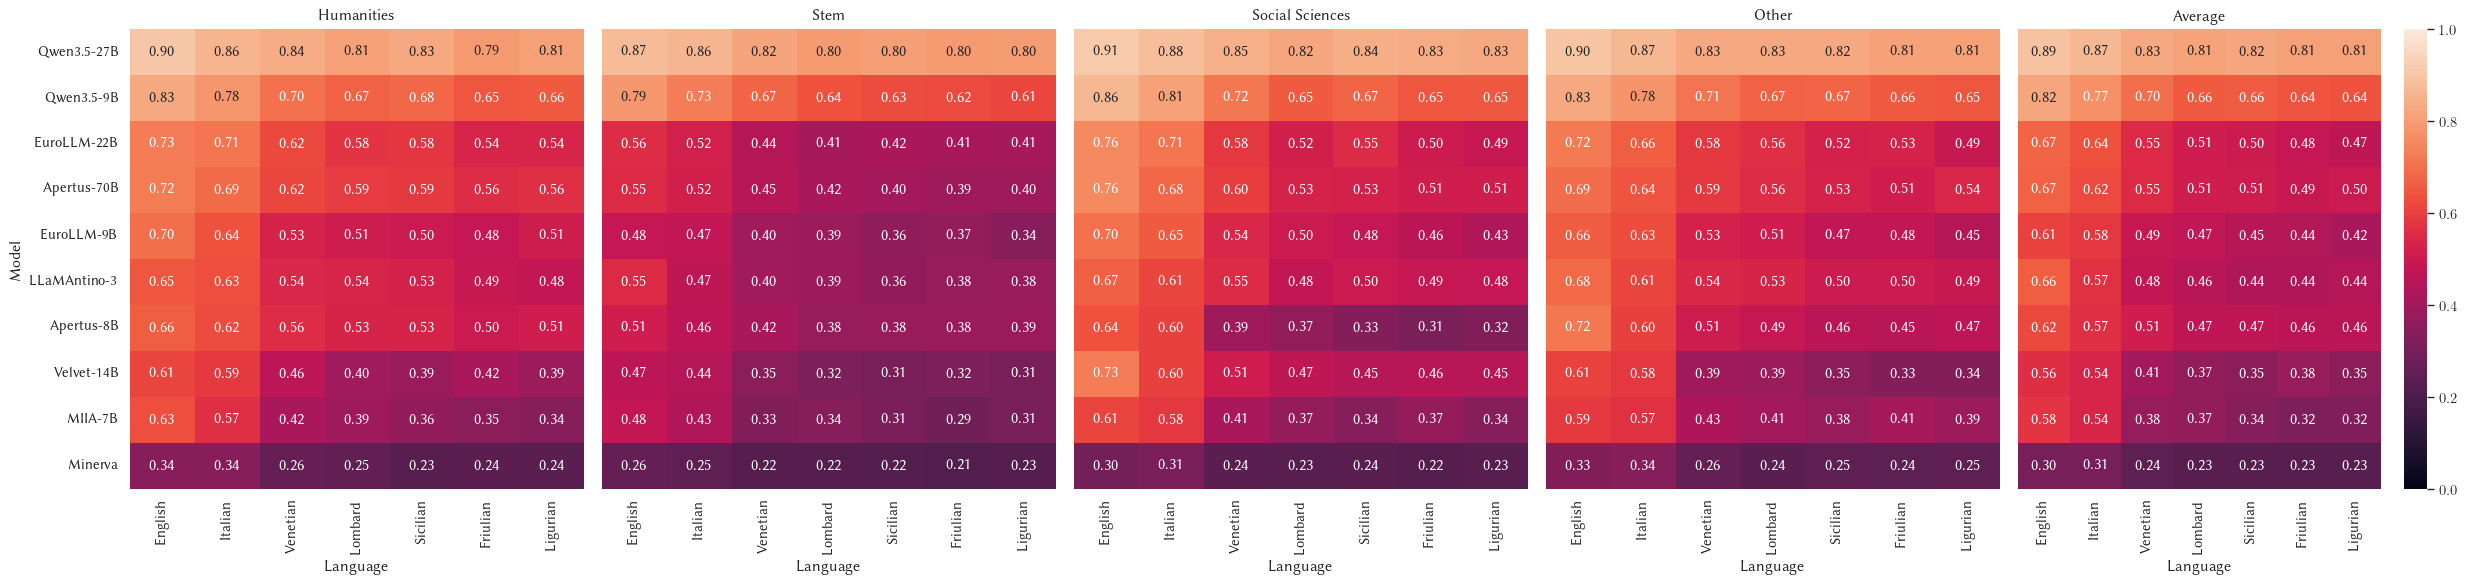

In [344]:
# heatmap (language x model) for each category
categories = [
    category for category in final_df["category"].cat.categories if category in set(final_df["category"].dropna())
]

fig, axes = plt.subplots(1, len(categories), figsize=(5 * len(categories), 6), sharey=True)
axes = np.atleast_1d(axes)

for i, category in enumerate(categories):
    ax = axes[i]
    heatmap_df = (
        final_df[final_df["category"] == category]
        .pivot_table(index="model", columns="lang", values="accuracy", observed=False)
        .reindex(index=MODELS_ORDER, columns=LANGS_ORDER)
    )

    heatmap_df.sort_values(by="Italian", ascending=False, inplace=True)  # Sort by English accuracy

    sns.heatmap(
        heatmap_df,
        ax=ax,
        annot=True,
        fmt=".2f",
        vmin=0.0,
        vmax=1.0,
        cbar=i == len(categories) - 1,
    )
    ax.set_title(str(category).title())
    ax.set_xlabel("Language")
    ax.set_ylabel("Model" if i == 0 else "")

plt.tight_layout()
plt.show()

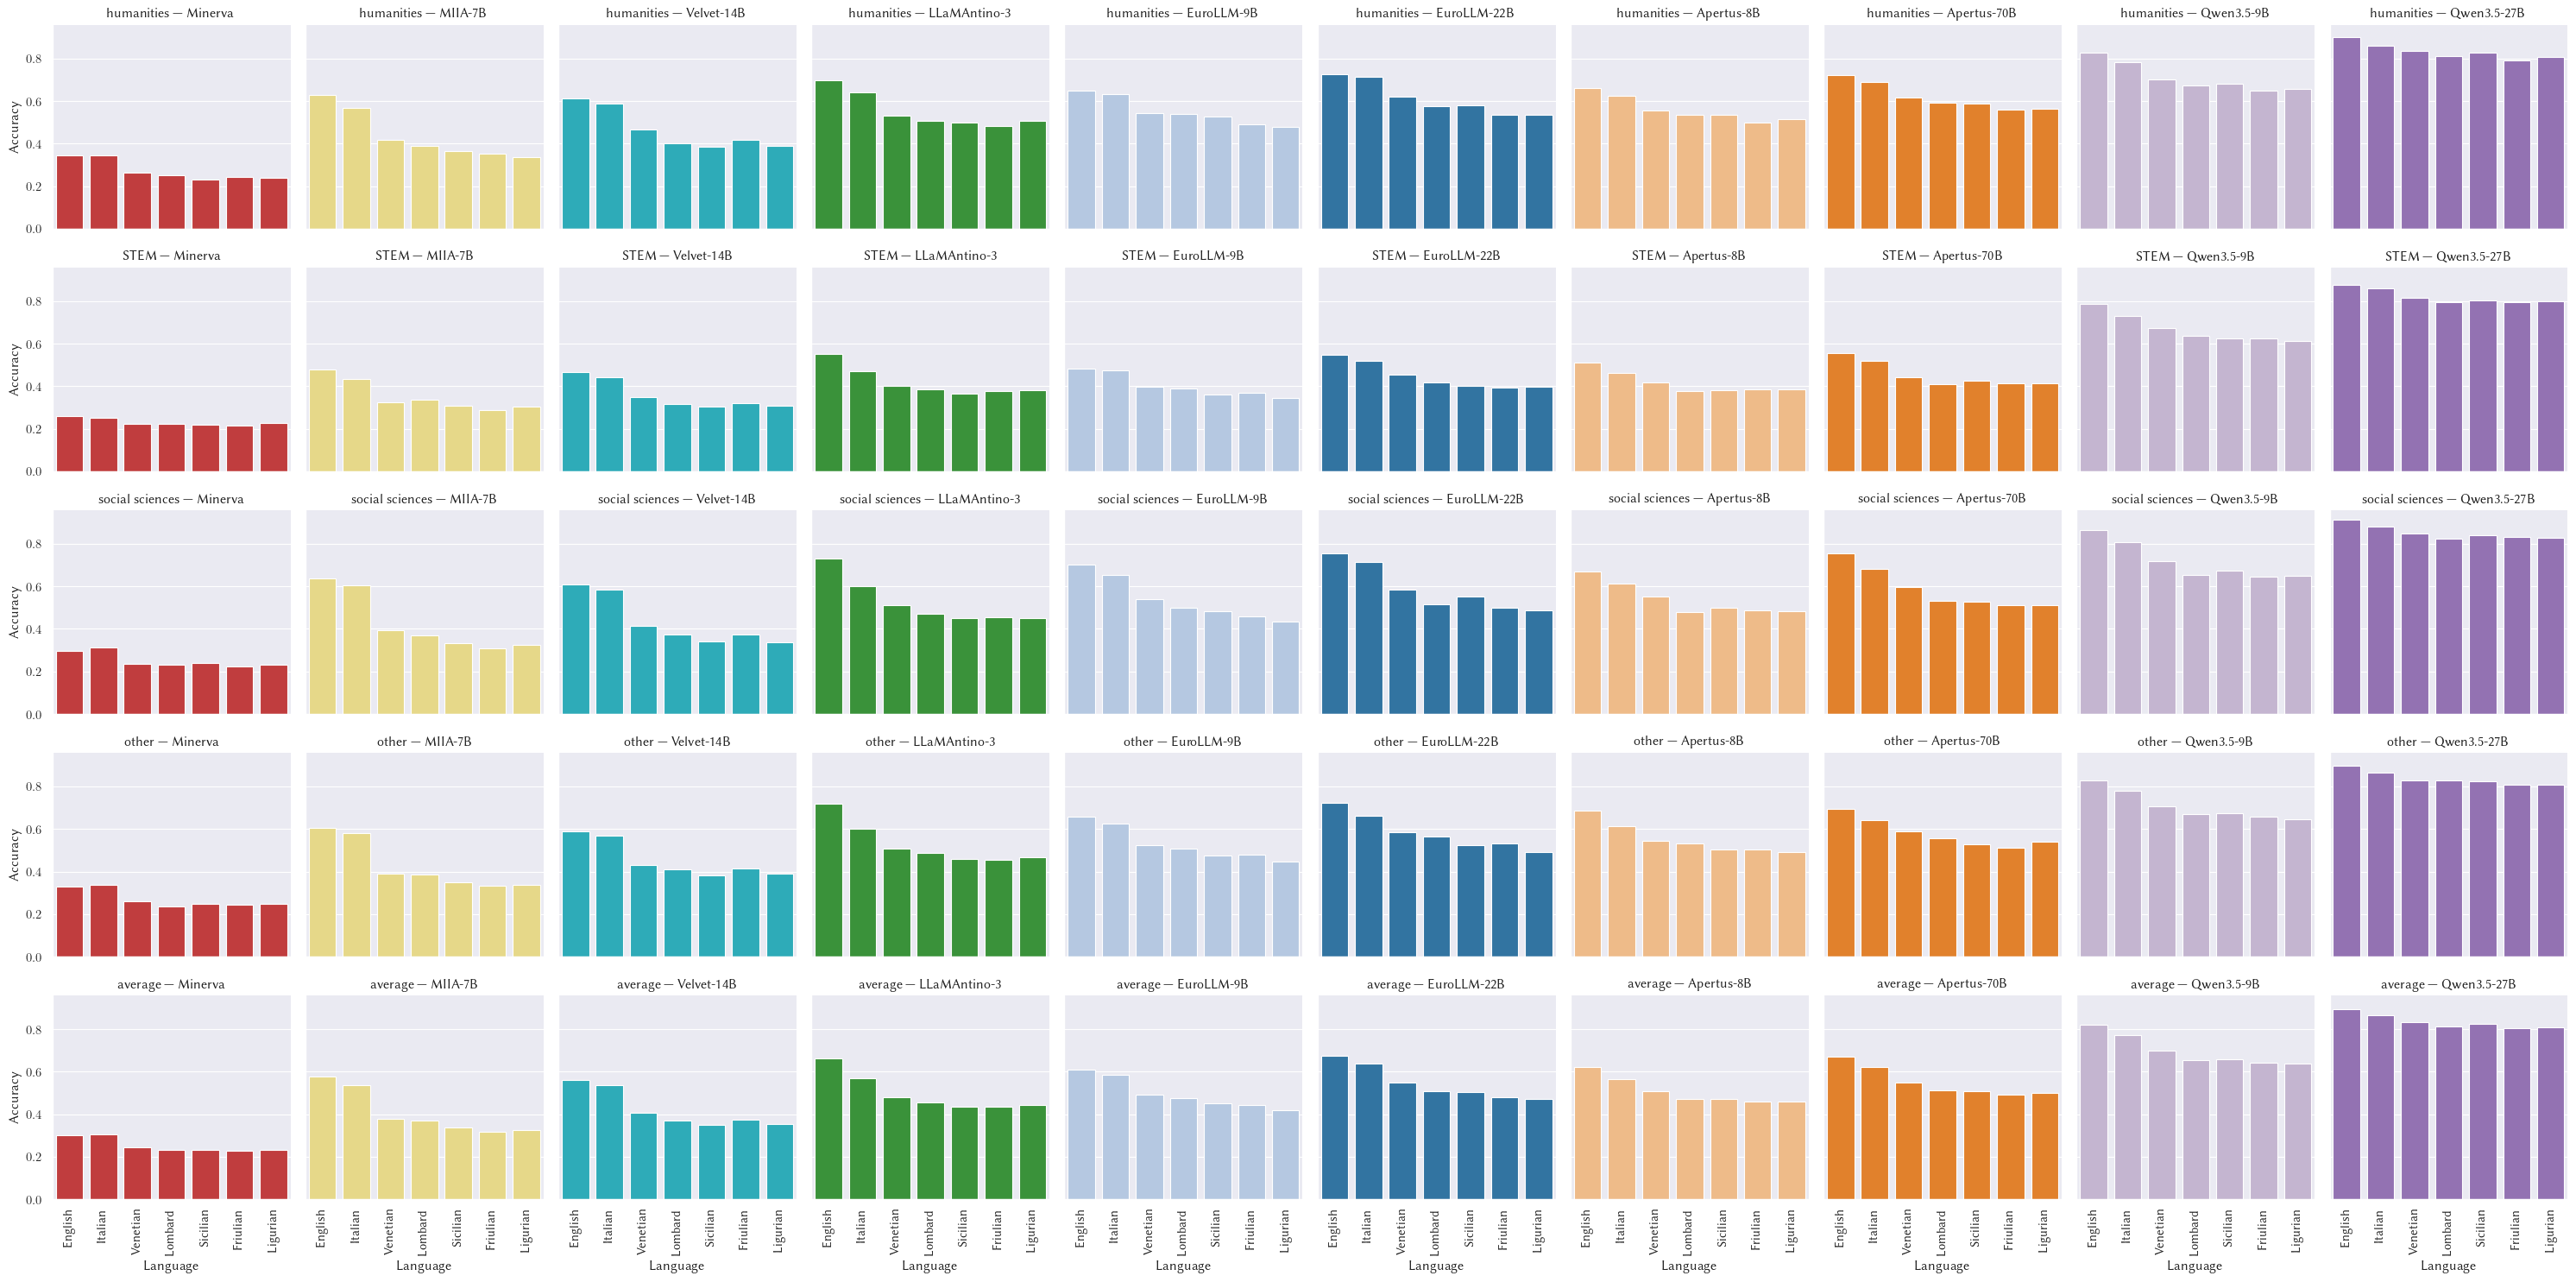

In [345]:
# per category plot
final_df = final_df.sort_values(["model", "category"])
sns.set_style("darkgrid")

g = sns.FacetGrid(final_df, row="category", col="model")
g.map_dataframe(sns.barplot, x="lang", y="accuracy", hue="model", palette=MODELS_COLORS)
g.set_titles(row_template="{row_name}", col_template="{col_name}")
g.set_xticklabels(labels=final_df["lang"].unique(), rotation=90)
g.set_axis_labels("Language", "Accuracy")
plt.tight_layout()
plt.show()